In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization,Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2

In [2]:
train_dir = "few_shot_dataset/train"
val_dir = "few_shot_dataset/test"
test_dir = "few_shot_dataset/val"

In [3]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 4

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    shear_range=0.1
)
val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

# =============================
# TRAIN DATA
# =============================
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # because you have 6 classes
    shuffle=True
)


# =============================
# VALIDATION DATA
# =============================
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =============================
# TEST DATA
# =============================
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 55 images belonging to 6 classes.
Found 50 images belonging to 6 classes.
Found 33 images belonging to 6 classes.


In [4]:
conv_base= MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

In [5]:
conv_base.trainable=True
set_trainable=False

for layer in conv_base.layers:
    if layer.name=='block_16_expand':
        set_trainable=True
    if set_trainable:
        layer.trainable=True
    else:
        layer.trainable=False
for layer in conv_base.layers:
    print(layer.name,layer.trainable)
         

input_layer False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu False
expanded_conv_project False
expanded_conv_project_BN False
block_1_expand False
block_1_expand_BN False
block_1_expand_relu False
block_1_pad False
block_1_depthwise False
block_1_depthwise_BN False
block_1_depthwise_relu False
block_1_project False
block_1_project_BN False
block_2_expand False
block_2_expand_BN False
block_2_expand_relu False
block_2_depthwise False
block_2_depthwise_BN False
block_2_depthwise_relu False
block_2_project False
block_2_project_BN False
block_2_add False
block_3_expand False
block_3_expand_BN False
block_3_expand_relu False
block_3_pad False
block_3_depthwise False
block_3_depthwise_BN False
block_3_depthwise_relu False
block_3_project False
block_3_project_BN False
block_4_expand False
block_4_expand_BN False
block_4_expand_relu False
block_4_depthwise False
block_4_depthwise_BN False
block_4_dep

In [6]:
conv_base.summary()

Model: "mobilenetv2_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 64, 64, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 64, 64, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 64, 64, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 64, 64, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 64, 64, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 64, 64, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 64, 64, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 64, 64, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 64, 64, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 64, 64, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 64, 64, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 65, 65, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 32, 32, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 886,080 (3.38 MB)

 Non-trainable params: 1,371,904 (5.23 MB)

In [7]:
model=Sequential([
    conv_base,
    Flatten(),
    # GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(6,activation='sigmoid')
])

In [16]:
# Apply Data Augmentation on train data.
train_datagen=ImageDataGenerator(rescale=1./255,
                                 horizontal_flip=True,
                                 rotation_range=20,
                                 zoom_range=0.2,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 fill_mode='nearest'   
                                )
# Train data 
train_data=train_datagen.flow_from_directory(train_dir,
                                    target_size=(128,128),
                                    batch_size=16,
                                    shuffle=True,
                                    seed=42,
                                    class_mode='sparse' 
                                    )
# Validation data
validation_data=train_datagen.flow_from_directory(val_dir,
                                  target_size=(128,128),
                                  batch_size=16,                                  
                                  class_mode='sparse',
                                  seed=42)
# Test data
test_datagen=ImageDataGenerator(rescale=1./255)                 #Scale test data
test_data=test_datagen.flow_from_directory(test_dir,
                                        target_size=(128,128),
                                        batch_size=16,
                                        shuffle=False,
                                        class_mode='sparse')

Found 55 images belonging to 6 classes.
Found 50 images belonging to 6 classes.
Found 33 images belonging to 6 classes.


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          81,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,340,358 (8.93 MB)

 Trainable params: 968,454 (3.69 MB)

 Non-trainable params: 1,371,904 (5.23 MB)

In [18]:
# Compile and train model:
# Optimizer:Adam

opt=tf.keras.optimizers.Adam(1e-5)

model.compile(optimizer=opt,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
es=EarlyStopping(monitor='val_loss',patience=5,verbose=1)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3)

cb=[es,reduce_lr]

In [30]:

hist=model.fit(
    train_data,
    epochs=100,verbose=1,
    validation_data=validation_data,
    callbacks=[cb]
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 368ms/step - accuracy: 0.2545 - loss: 2.4205 - val_accuracy: 0.1200 - val_loss: 2.8462 - learning_rate: 2.5000e-06
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.2545 - loss: 2.6645 - val_accuracy: 0.1200 - val_loss: 2.8053 - learning_rate: 2.5000e-06
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.2545 - loss: 2.6629 - val_accuracy: 0.1200 - val_loss: 2.6937 - learning_rate: 2.5000e-06
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - accuracy: 0.1818 - loss: 2.6495 - val_accuracy: 0.1200 - val_loss: 2.7961 - learning_rate: 2.5000e-06
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step - accuracy: 0.2727 - loss: 2.4047 - val_accuracy: 0.1200 - val_loss: 2.7439 - learning_rate: 2.5000e-06
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 359ms/step - accuracy: 0.2545 - loss: 2.7864 - val_accuracy: 0.1000 - val_loss: 2.6708 - learning_rate: 2.5000e-06
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 0.2545 

In [21]:
import matplotlib.pyplot as plt
import  numpy as np

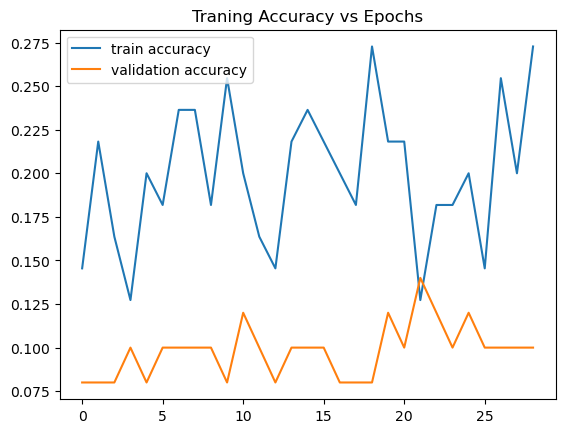

In [22]:
plt.title('Traning Accuracy vs Epochs')
plt.plot(hist.history['accuracy'],label='train accuracy')
plt.plot(hist.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

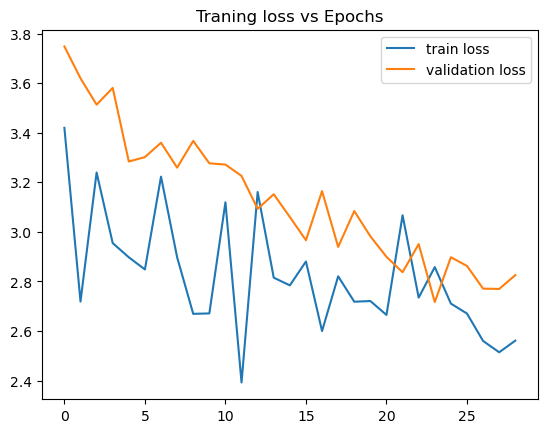

In [23]:
plt.title('Traning loss vs Epochs')
plt.plot(hist.history['loss'],label='train loss')
plt.plot(hist.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

In [25]:
prediction=model.predict(test_data)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 621ms/step


In [27]:
y_pred = np.argmax(prediction, axis=1)
y_true=test_data.classes
print(len(y_true))
print(len(y_pred))

33
33


Test Accuracy:0.24242424242424243
Test Precision:0.19444444444444445
Test Recall:0.22916666666666666
Test F1:0.13852813852813853


C:\Users\Kinza\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


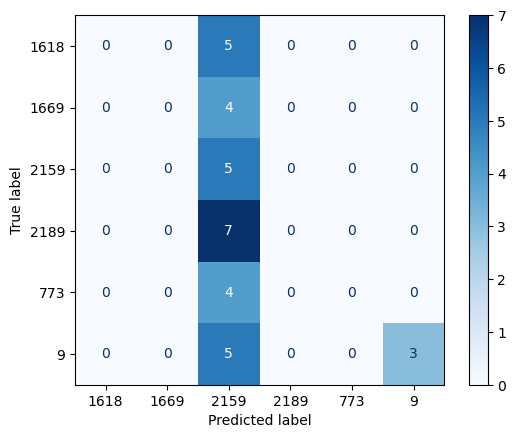

In [29]:
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
acc=accuracy_score(y_true,y_pred)
pre=precision_score(y_true,y_pred,average='macro')
re=recall_score(y_true,y_pred,average='macro')
fs=f1_score(y_true,y_pred,average='macro')
cm=confusion_matrix(y_true,y_pred)
print(f'Test Accuracy:{acc}')
print(f'Test Precision:{pre}')
print(f'Test Recall:{re}')
print(f'Test F1:{fs}')
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=validation_data.class_indices.keys())
disp.plot(cmap='Blues')
plt.show()